In [1123]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score, RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import make_pipeline

Importando os data-sets e visualizando os dados

In [1124]:
train_df = pd.read_csv('train.csv', index_col=[0])
test_df = pd.read_csv('test.csv', index_col=[0])

In [1125]:
train_df.head()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,Hernia
1,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,Hernia
2,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,Hernia
3,40.250200,13.921907,25.124950,26.328293,130.327871,2.230652,Hernia
4,53.432928,15.864336,37.165934,37.568592,120.567523,5.988551,Hernia


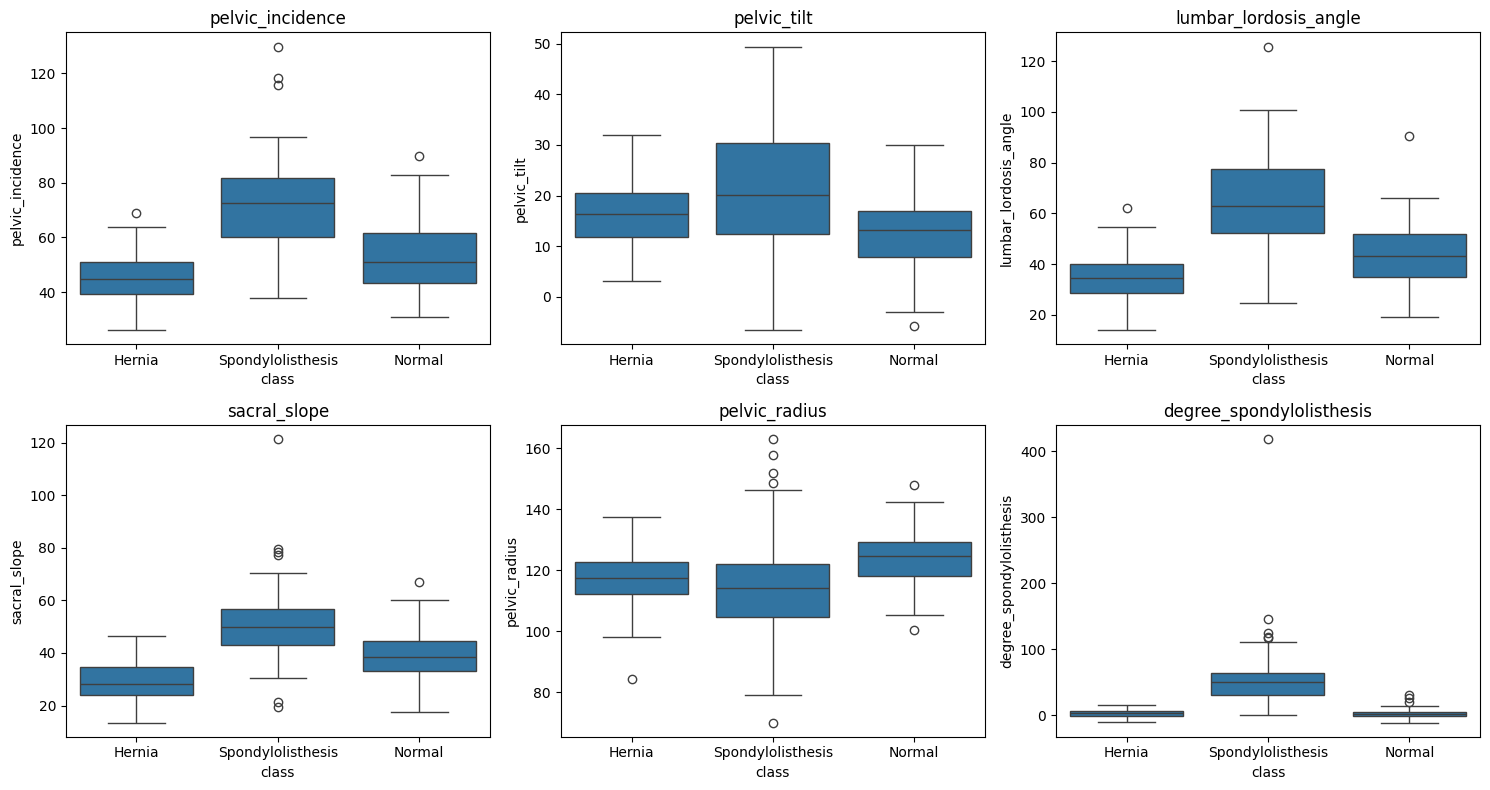

In [1126]:
feature_cols = [c for c in train_df.columns if c != 'class']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, feature_cols):
    sns.boxplot(data=train_df, x='class', y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

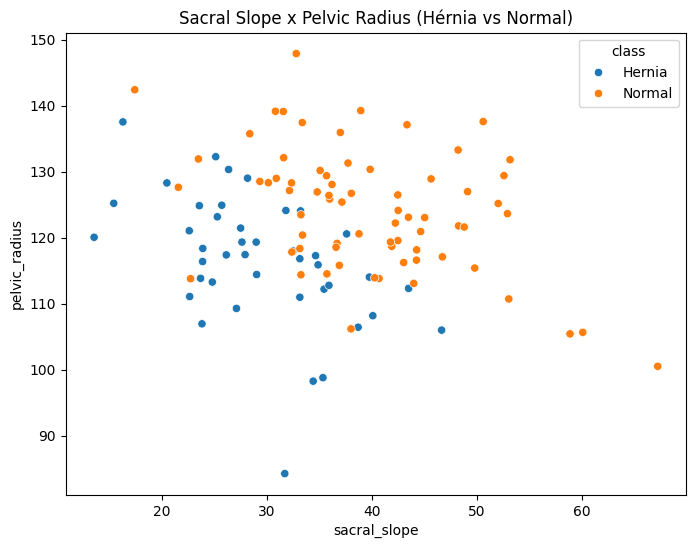

In [1127]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=train_df[train_df['class'] != 'Spondylolisthesis'],
    x='sacral_slope', y='pelvic_radius', hue='class'
)
plt.title('Sacral Slope x Pelvic Radius (Hérnia vs Normal)')
plt.show()

Dividindo o dataset de treino: 80% treino e 20% teste

In [ ]:
train_df['degree_spondylolisthesis'] = train_df['degree_spondylolisthesis'].clip(lower=0, upper=110)
train_df['pelvic_incidence'] = train_df['pelvic_incidence'].clip(lower=30, upper=95)
train_df['sacral_slope'] = train_df['sacral_slope'].clip(lower=10, upper=70)

test_df['degree_spondylolisthesis'] = test_df['degree_spondylolisthesis'].clip(lower=0, upper=110)
test_df['pelvic_incidence'] = test_df['pelvic_incidence'].clip(lower=30, upper=95)
test_df['sacral_slope'] = test_df['sacral_slope'].clip(lower=10, upper=70)

In [1129]:
X = train_df.drop(columns=['class'])
y = train_df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

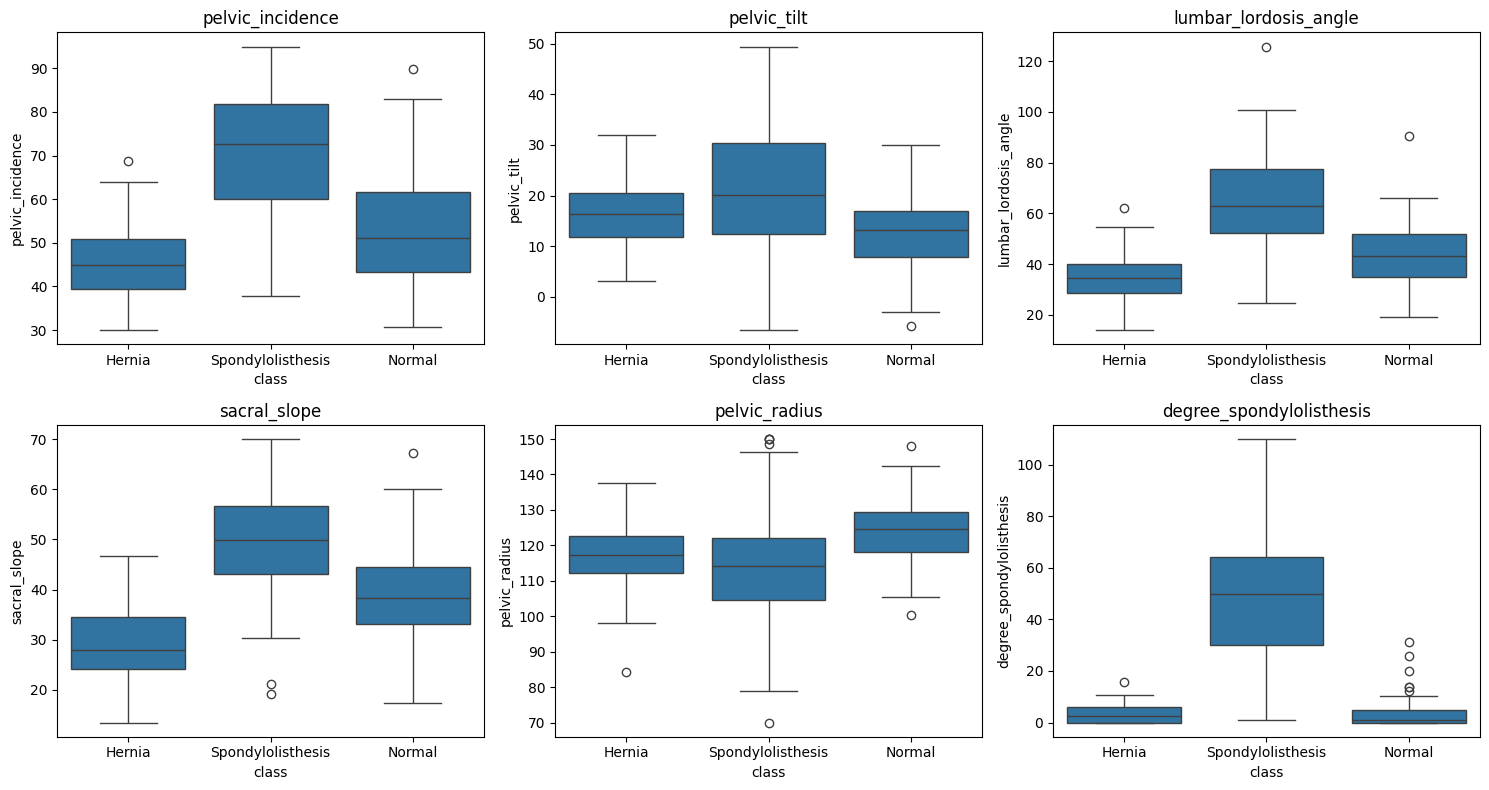

In [1130]:
feature_cols = [c for c in train_df.columns if c != 'class']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, feature_cols):
    sns.boxplot(data=train_df, x='class', y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Definindo parâmetros para a validação cruzada

In [1131]:
param_grid_stage1 = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, None],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf': [1, 2, 3, 5, 8],
    'class_weight': [None, 'balanced']  # Hérnia tende a ser a classe minoritária
}

param_grid_stage2 = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [2, 3, 4, 5, 6, 7, None],
    'min_samples_split': [2, 3, 4, 5, 6, 8, 10],
    'min_samples_leaf': [5, 6, 8, 10],
    'class_weight': [None, 'balanced']
}

In [1132]:
model = DecisionTreeClassifier(random_state=42)

In [1133]:
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.         0.00550509 0.00578035 0.00867052 0.00899165 0.00924855
 0.01109827 0.01114781 0.01280026 0.01801667 0.02987995 0.03243085
 0.06439853 0.34642826]


Grid Search

In [1134]:
y_stage1_train = (y_train == 'Spondylolisthesis').astype(int)
y_stage1_test = (y_test == 'Spondylolisthesis').astype(int)  # útil pra avaliar a Etapa 1 sozinha

grid_stage1 = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_stage1,
    cv=cv,
    scoring='accuracy' 
)
grid_stage1.fit(X_train, y_stage1_train)
model_stage1 = grid_stage1.best_estimator_


In [1135]:
# Etapa 2: só nos dados que NÃO são Spondylolisthesis
mask_nao_spondy = y_train != 'Spondylolisthesis'
X_train_stage2 = X_train[mask_nao_spondy]
y_train_stage2 = y_train[mask_nao_spondy]  # só Hernia ou Normal


smote = SMOTE(random_state=42, sampling_strategy=0.8, k_neighbors=3)
X_train_stage2_bal, y_train_stage2_bal = smote.fit_resample(X_train_stage2, y_train_stage2)

# Treina a árvore com os dados balanceados
model_stage2_v3 = DecisionTreeClassifier(random_state=42, max_depth=4, min_samples_leaf=3)
model_stage2_v3.fit(X_train_stage2_bal, y_train_stage2_bal)

grid_stage2 = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_stage2,
    cv=cv,
    scoring='accuracy' 
)
grid_stage2.fit(X_train_stage2, y_train_stage2)


/Users/marcelazarichta/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'class_weight': [None, 'balanced'],
                         'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [2, 3, 4, 5, 6, 7, None],
                         'min_samples_leaf': [5, 6, 8, 10],
                         'min_samples_split': [2, 3, 4, 5, 6, 8, 10]},
             scoring='accuracy')

In [1136]:
# Predição em cascata
def predict_hierarquico(X):
    pred_stage1 = model_stage1.predict(X)
    final_preds = np.where(pred_stage1 == 1, 'Spondylolisthesis', None)
    
    idx_resto = np.where(pred_stage1 == 0)[0]
    if len(idx_resto) > 0:
        pred_stage2 = model_stage2_v3.predict(X.iloc[idx_resto])
        final_preds[idx_resto] = pred_stage2
    
    return final_preds

In [1137]:
from sklearn.metrics import classification_report


pred_stage1_test = model_stage1.predict(X_test)

print("STAGE 1")
print(classification_report(
    y_stage1_test,
    pred_stage1_test,
    target_names=[
        'Não Spondylolisthesis',
        'Spondylolisthesis'
    ]
))

STAGE 1
                       precision    recall  f1-score   support

Não Spondylolisthesis       0.96      1.00      0.98        23
    Spondylolisthesis       1.00      0.95      0.98        21

             accuracy                           0.98        44
            macro avg       0.98      0.98      0.98        44
         weighted avg       0.98      0.98      0.98        44



In [1138]:
mask_test_nao_spondy = y_test != 'Spondylolisthesis'

X_test_stage2 = X_test[mask_test_nao_spondy]
y_test_stage2 = y_test[mask_test_nao_spondy]

pred_stage2_test = grid_stage2.best_estimator_.predict(X_test_stage2)

print("STAGE 2")
print(classification_report(y_test_stage2, pred_stage2_test))

STAGE 2
              precision    recall  f1-score   support

      Hernia       0.62      0.56      0.59         9
      Normal       0.73      0.79      0.76        14

    accuracy                           0.70        23
   macro avg       0.68      0.67      0.67        23
weighted avg       0.69      0.70      0.69        23



In [1139]:
print("Melhores parâmetros Stage 1:")
print(grid_stage1.best_params_)

print("\nScore CV Stage 1:")
print(grid_stage1.best_score_)

print("\nMelhores parâmetros Stage 2:")
print(grid_stage2.best_params_)

print("\nScore CV Stage 2:")
print(grid_stage2.best_score_)

Melhores parâmetros Stage 1:
{'class_weight': None, 'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}

Score CV Stage 1:
0.9710924369747899

Melhores parâmetros Stage 2:
{'class_weight': None, 'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 6, 'min_samples_split': 2}

Score CV Stage 2:
0.7869281045751635


In [1140]:
# Pega as previsões e identifica os erros de Hérnia/Normal no X_test
predictions = predict_hierarquico(X_test)
mask_stage2 = (y_test.values != 'Spondylolisthesis') & (predictions != 'Spondylolisthesis')
erros_mask = mask_stage2 & (y_test.values != predictions)

X_test_stage2 = X_test[mask_stage2]
casos_errados = X_test[erros_mask]

# Qual folha cada caso errado caiu (usando a árvore final, ex: model_stage2_v3)
folhas = model_stage2_v3.apply(casos_errados)

print("Casos errados e a folha onde caíram:")
for idx, folha in zip(casos_errados.index, folhas):
    print(f"Índice {idx} -> nó folha {folha}")
    print(casos_errados.loc[idx])
    print('---')

Casos errados e a folha onde caíram:
Índice 166 -> nó folha 7
pelvic_incidence             37.731992
pelvic_tilt                   9.386298
lumbar_lordosis_angle        42.000000
sacral_slope                 28.345694
pelvic_radius               135.740926
degree_spondylolisthesis     13.683047
lombar_lordosis_angle        42.000000
Name: 166, dtype: float64
---
Índice 155 -> nó folha 10
pelvic_incidence             64.311867
pelvic_tilt                  26.328369
lumbar_lordosis_angle        50.958964
sacral_slope                 37.983498
pelvic_radius               106.177751
degree_spondylolisthesis      3.118221
lombar_lordosis_angle        50.958964
Name: 155, dtype: float64
---
Índice 18 -> nó folha 3
pelvic_incidence             30.000000
pelvic_tilt                  10.759454
lumbar_lordosis_angle        14.000000
sacral_slope                 15.388468
pelvic_radius               125.203296
degree_spondylolisthesis      0.000000
lombar_lordosis_angle        14.000000
Name: 18,

In [1141]:
predictions = predict_hierarquico(X_test)
final_predictions = predict_hierarquico(test_df)

Resultados

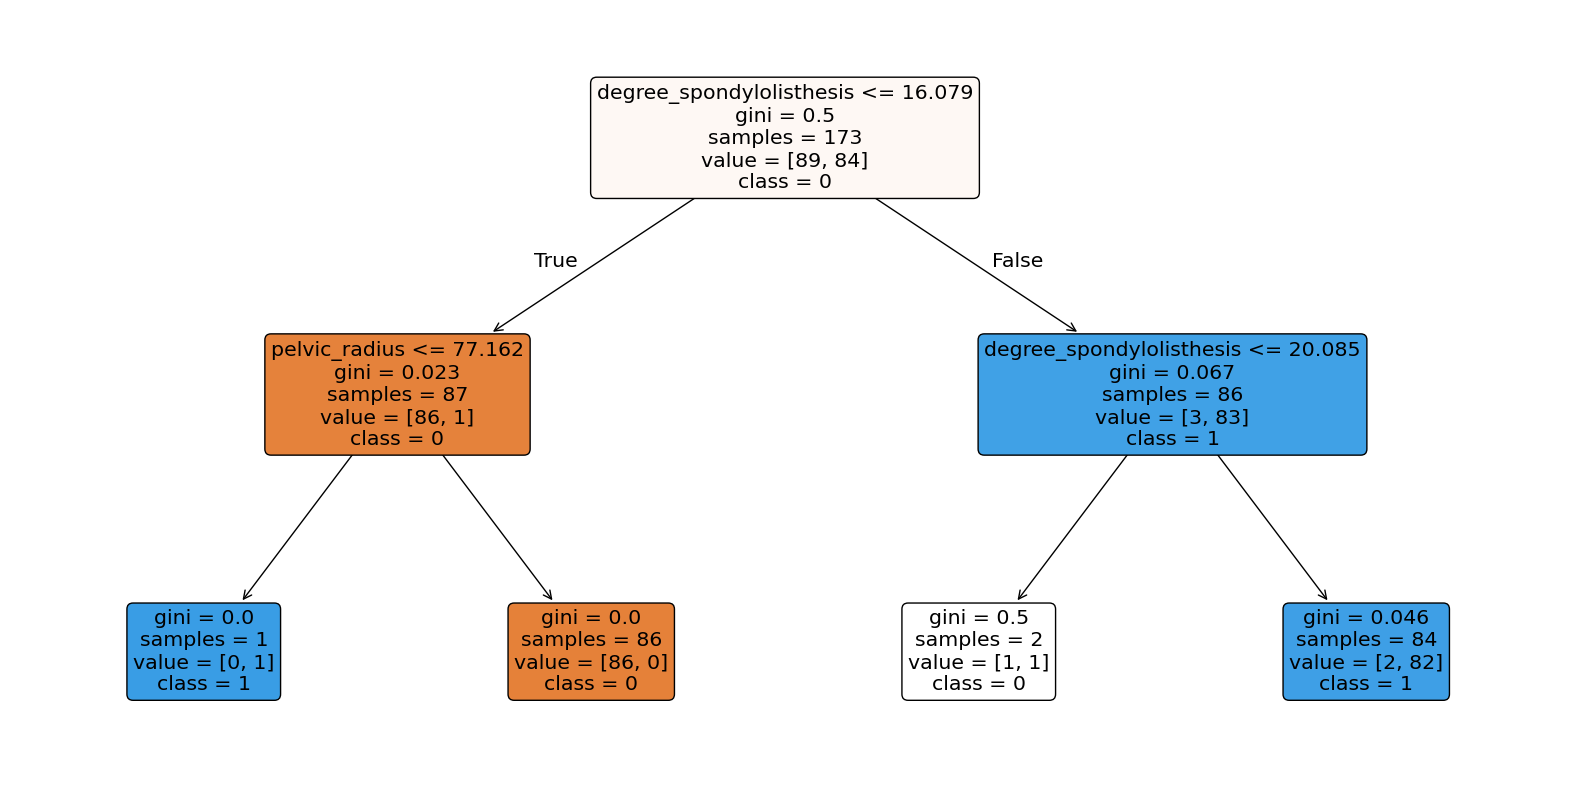

In [1142]:
plt.figure(figsize=(20, 10))

plot_tree(
    model_stage1,
    feature_names=X_train_stage2.columns,
    class_names=[str(c) for c in model_stage1.classes_],
    filled=True,
    rounded=True
)

plt.show()

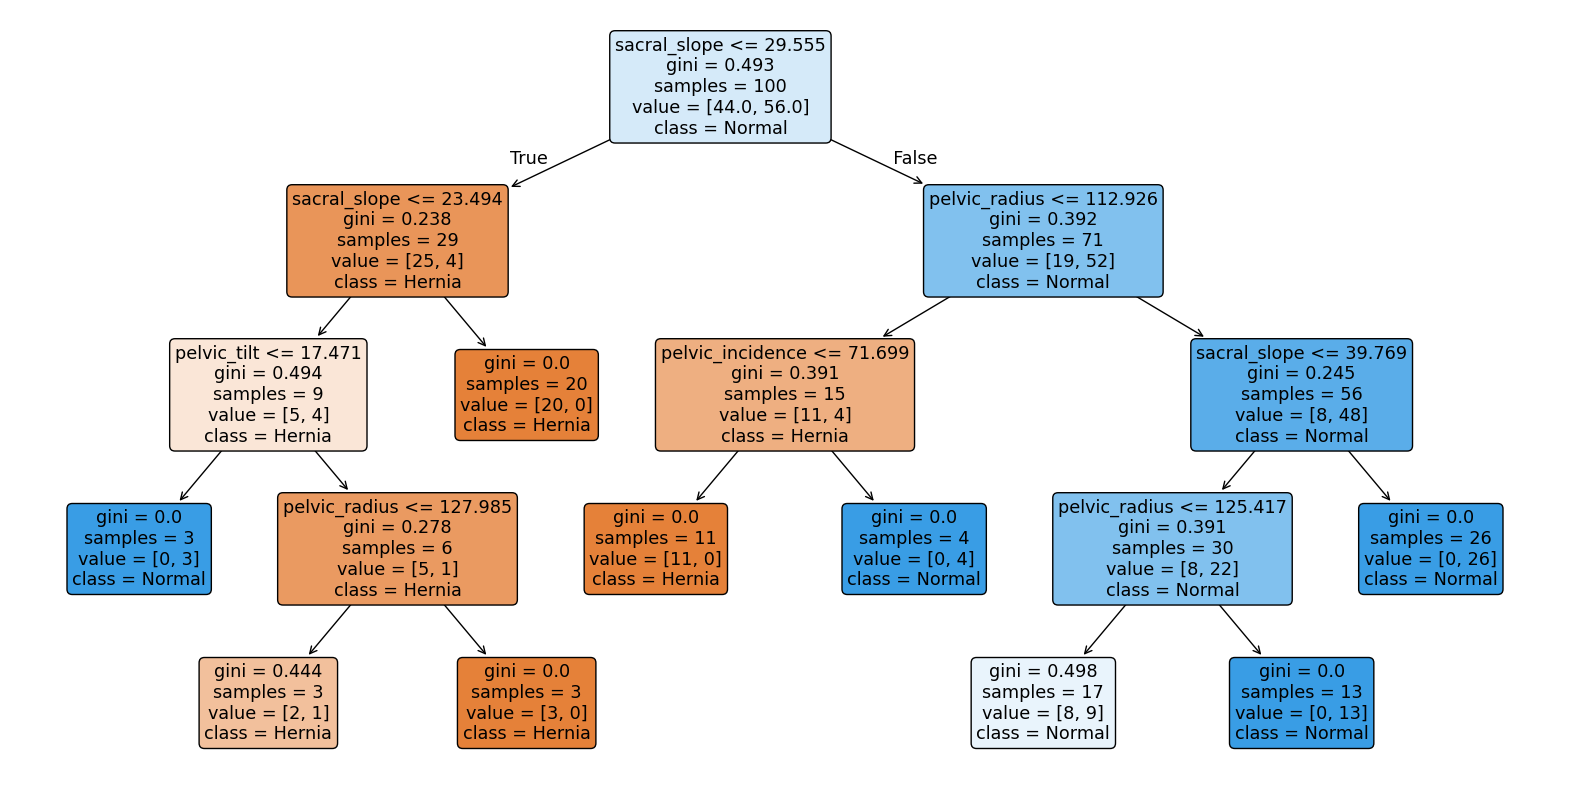

In [1143]:
plt.figure(figsize=(20, 10))

plot_tree(
    model_stage2_v3,
    feature_names=X_train_stage2.columns,
    class_names=model_stage2_v3.classes_,
    filled=True,
    rounded=True
)

plt.show()

In [1144]:
modelo_stage2 = grid_stage2.best_estimator_

importancias = pd.Series(
    modelo_stage2.feature_importances_,
    index=X_train_stage2.columns
).sort_values(ascending=False)

print(importancias)

sacral_slope                0.661507
pelvic_radius               0.231018
lombar_lordosis_angle       0.107474
pelvic_incidence            0.000000
pelvic_tilt                 0.000000
lumbar_lordosis_angle       0.000000
degree_spondylolisthesis    0.000000
dtype: float64


In [1145]:
print('Accuracy:', accuracy_score(y_test, predictions))
print('F1:', f1_score(y_test, predictions, average='macro'))
print('Precision:', precision_score(y_test, predictions, average='macro'))
print('Recall:', recall_score(y_test, predictions, average='macro'))

Accuracy: 0.8636363636363636
F1: 0.8327220490250015
Precision: 0.8285714285714286
Recall: 0.8386243386243386


Matriz de confusão

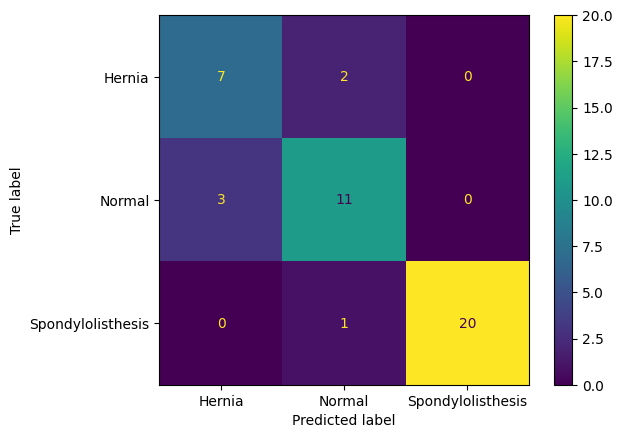

In [1146]:
ConfusionMatrixDisplay.from_predictions(y_test, predictions)

Criando arquivo de submissão

In [1147]:
def create_submission_file(predictions, test_df, submission_file_name="submission.csv"):
    submission_df = pd.DataFrame({'id': test_df.index, 'Target': predictions})
    submission_df.to_csv(submission_file_name, index=False)
    print(f"Submission file '{submission_file_name}' created successfully.")

In [1148]:
create_submission_file(final_predictions, test_df)

Submission file 'submission.csv' created successfully.
